In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import dill
import os
import distances as dsts
from particles_cdssm.sdes import IntegratedFitzhughNagumo
import particles_cdssm.auxiliary_bridges as axb

# Figure 4: Left: Plot of the CD-SSM used in the Numerical Experiment. Right: Simulation of path $\bar{X}([s_{t-1}, s_t])$ for $x(s_{t-1}) \approx (-1.01, -6.92)$ via locally Gaussian scheme with $k=1000$ imputed points. 

## Load the simulation of the FHN used in the numerical experiment

In [2]:
T = 100
run_id = 100

with open(f'../fhn_smoothing/results/run_{run_id}_meta.pkl', 'rb') as f:
    metadata = dill.load(f)

# Unpack the metadata
x, y = metadata['x'], metadata['y']
cdssm = metadata['cdssm']

T = len(y)
S = cdssm.s_ts * T
num = 50

sde_paths = np.concatenate([np.concatenate([x[i][name] for name in x[0].dtype.names]) for i in range(T)])
sim_times = np.linspace(start=0., stop=S, num=(sde_paths.shape[0] + 1))[1:]

obs_times = np.linspace(start=0., stop=S, num=(T+1))[1:]
e_ts = np.stack([sde_paths[1000*(i+1) - 1, :] for i in range(T)])
observations = np.array(y).ravel()

## Simulate sample paths of $\tilde{X}([s_{t-1}, s_t])$ using the locally Gaussian scheme

In [3]:
np.random.seed(3445)
sde = IntegratedFitzhughNagumo()
N=5000
num=1000
x_0 = e_ts[22]

sims = sde.simulate_ldl(N, x_start=np.stack([x_0]*N, axis=0), delta_t=0.05, num=num) # (num, N, dimX)
sims = np.concatenate([np.stack([x_0]*N, axis=0).reshape(1, N, 2), sims], axis=0)

## Produce the Plot

/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_98769/1324694871.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


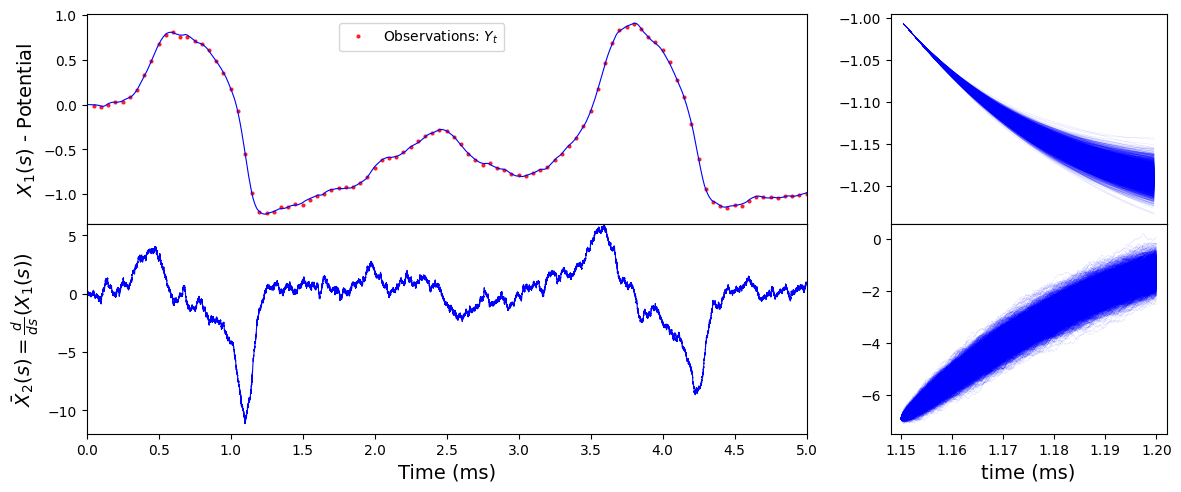

In [4]:
fig = plt.figure(figsize=(12, 5))
ax_0 = fig.add_axes((0.08, 0.52, 0.6, 0.42))
ax_1 = fig.add_axes((0.08, 0.1, 0.6, 0.42))
ax_2 = fig.add_axes((0.75, 0.52, 0.23, 0.42))
ax_3 = fig.add_axes((0.75, 0.1, 0.23, 0.42))

labels = [r'$X_1(s)$' + ' - Potential', r'$\bar{X}_2(s)=\frac{d}{ds}(X_1(s))$']
xy_label_size = 14

ax_0.plot(obs_times, observations, 'o', markersize=2.0, color='red', alpha=0.8, label='Observations: ' + r'$Y_t$')
ax_0.plot(sim_times, sde_paths[:, 0], color='blue', linewidth=0.8, linestyle='-', marker=None)
ax_1.plot(sim_times, sde_paths[:, 1], color='blue', linewidth=0.8, linestyle='-', marker=None)

ax_0.set(xticklabels=[], xticks=np.arange(0., 5.5, 0.5).tolist(), xlim=(0.0, 5.0))
ax_1.set(xlim=(0.0, 5.0), ylim=(-12.0, 6.0), xticks=np.arange(0., 5.5, 0.5).tolist())

ax_0.set_ylabel(labels[0], fontsize=xy_label_size)
ax_1.set_ylabel(labels[1], fontsize=xy_label_size)
ax_1.set_xlabel(xlabel='Time (ms)', fontsize=xy_label_size)

ax_0.legend(loc='upper right', bbox_to_anchor=(0.59, 0.99))

x = np.linspace(start=1.15, stop=1.2, num=(num+1))
line_kwargs = dict(marker='none', lw=0.2, ls='-', alpha=0.2)

ax_2.plot(x, sims[:, :, 0], color='blue', **line_kwargs)
ax_3.plot(x, sims[:, :, 1], color='blue', **line_kwargs)

ax_2.set(ylabel='', xticklabels=[]) # xticks=[0., 1., 2., 3., 4., 5.], 
ax_3.set(ylabel='', xlim=(1.148, 1.202)) # xticks=[0., 1., 2., 3., 4., 5.]
ax_3.set_xlabel('time (ms)', fontsize=xy_label_size)

plt.tight_layout()
plt.savefig('./figures/fig_4_fhn_simulation.pdf', dpi=600)
plt.show()

# Figure 6: Contour plots of transition density approximations $\tilde{p}_t^{(k)}(\cdot|e_{t-1})$ for $k \in \{1, 2, 5, 10\}$ from the locally Gaussian scheme to compare against a contour plot of $p_t(\cdot|e_{t-1})\approx \tilde{p}^{(1000)}(\cdot|e_{t-1})$: $e_{t-1}\approx(-1.01, -6.92)^T$. Bottom right: Bar plot of $\mathcal{L}_2$ distances between the true transition density and the approximations for increasing values of $k$. When $k>1$, the density is found using a Gaussian KDE with $l=5000$ simulated points.

## Define parameters

In [5]:
N_kde = 5000 # Number of samples to calculate the KDEs
true_k = 1000 # Number of points imputed to obtain 'true' transition density.
k_s = [2, 5, 10] # Values of k (excluding 1) to test

n_replicates_conf = 2 # Number of replicates to come up with the confidence interval.

# Mean and Cov of locally Gaussian scheme
mu = sde.mu_ldl(x_0.reshape(1, -1), 0.05)
S = sde.S_ldl(0.05)

# Take sample to represent true transtition densitty as the marginal of $X(s_t$)$ in figure 4.
true_sample = sims[-1].T

## Generate data need for the plot

In [6]:
## Generate samples and create KDES for $k=\{2, 5, 10\}$

samples = [sde.simulate_ldl(N_kde, x_start=np.stack([x_0]*N_kde, axis=0), delta_t=0.05, num=k_s[i])[-1].T for i in range(len(k_s))]    
mvn = stats.multivariate_normal(mean=mu.ravel(), cov=S)
kdes = [stats.gaussian_kde(sample) for sample in samples]
true_kde = stats.gaussian_kde(true_sample)

def gen_diff_func(kde):
    def diff_func(x):
        return kde.evaluate(x)
    return diff_func

def ldl_1_pdf(x):
    return mvn.pdf(x.T)

bv_functions = [ldl_1_pdf] + [kde.pdf for kde in kdes]

# Calculate L_2 distances for each of the samples.

l_2_distances = np.empty((len(k_s) +1, ))
l_2_distances[0] = dsts.kde_l2_distance(true_sample, mu.ravel(), S)

for i in range(len(k_s)):
    l_2_distances[i+1] = dsts.kdes_l2_distance(samples[i], true_sample)
    
# Calculate the 95% confidence error line in the bar plot:

filename = "l_2_distances.npy"

if os.path.isfile(filename):
    conf_l2_distances = np.load(filename)
else:
    conf_l2_distances = np.empty((n_replicates_conf, ), dtype=np.float64)
    for i in range(n_replicates_conf):
        sample = sde.simulate_ldl(N_kde, x_start=np.stack([x_0]*N_kde, axis=0), delta_t=0.05, num=true_k)[-1].T
        l_2_distance = dsts.kdes_l2_distance(sample, true_sample)
        conf_l2_distances[i] = l_2_distance

y_errorline = np.quantile(conf_l2_distances, q=0.95)

## Produce the plot 

/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_98769/2292904080.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


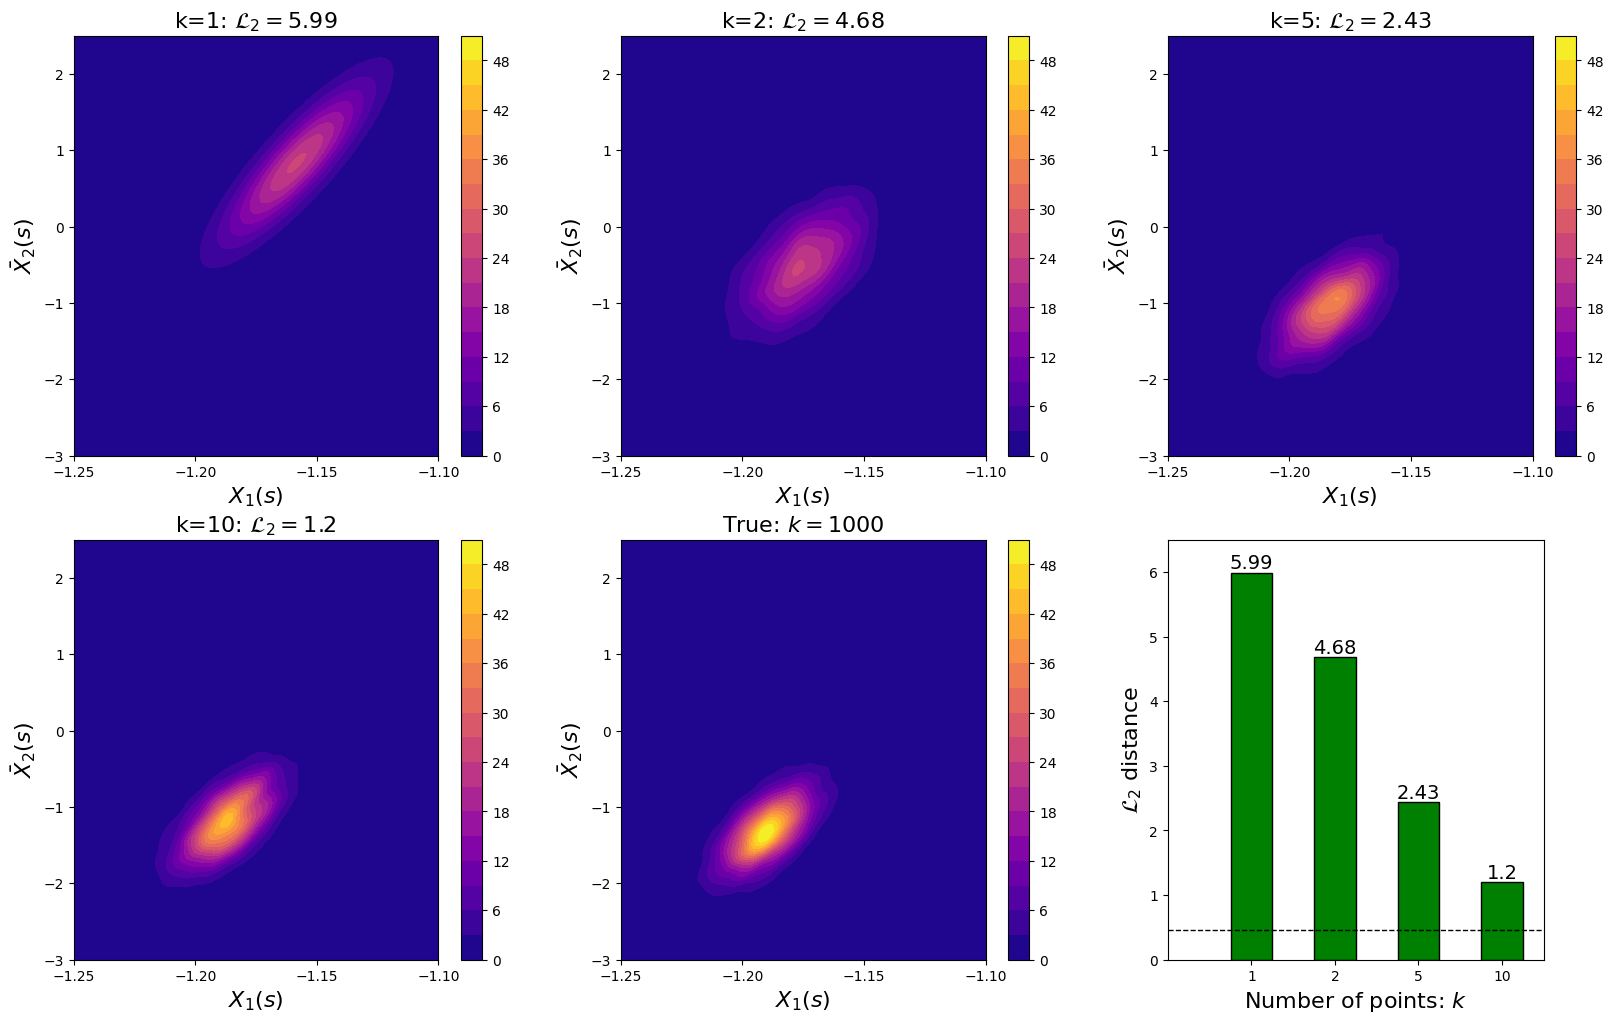

In [7]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3)  # default wspace/hspace

axes = []
for r in range(2):
    row = []
    for c in range(3):
        if (r == 1 and c == 2):
            continue
        bbox = gs[r, c].get_position(fig)     # Bbox in figure coordinates
        ax = fig.add_axes(bbox.bounds)        # bounds -> (x0, y0, width, height)
        # ax.imshow(np.random.randn(10, 10))
        # ax.set_title(f"Panel {r * 3 + c + 1}")
        row.append(ax)
    axes.append(row)

bbox = gs[1, 2].get_position(fig)
ax = fig.add_axes([bbox.x0, bbox.y0, bbox.width - 0.04, bbox.height])
axes[1].append(ax)

axes = np.array(axes, dtype=object)
axes = axes.ravel()

contour_axes = axes[:-2]
true_ax = axes[-2]
bar_ax = axes[-1]

# Contour plots
xmin=-1.25; xmax=-1.1; nx=100
ymin=-3.0; ymax=2.5; ny=100

levels = np.arange(0., 54., 3.0)

xs = np.linspace(start=xmin, stop=xmax, num=nx)
ys = np.linspace(start=ymax, stop=ymin, num=ny)

X, Y = np.meshgrid(xs, ys, indexing='xy')
pts = np.stack([X.ravel(), Y.ravel()], axis=0) # (2, nx*ny)

labels = [f'k=1: ' + r'$\mathcal{L}_2 = $' + str(round(l_2_distances[0], 2))] + [f'k={k}: ' + r'$\mathcal{L}_2 = $' + str(round(l_2_distances[i+1], 2)) for i, k in enumerate(k_s)]
x_y_fontsize=16

for i, ax in enumerate(contour_axes.ravel()):
    Z = bv_functions[i](pts).reshape(X.shape[0], X.shape[1])
    qcs = ax.contourf(X, Y, Z, levels=levels, cmap='plasma')
    fig.colorbar(qcs, ax=ax)
    ax.set(xticks=(-1.25, -1.2, -1.15, -1.1), xlabel=r'$X_1(s)$', ylabel=r'$\bar{X}_2(s)$')
    ax.set_title(labels[i], fontsize=x_y_fontsize)
    ax.xaxis.label.set_fontsize(x_y_fontsize)
    ax.yaxis.label.set_fontsize(x_y_fontsize)
    # np.linspace(start=0.0, stop=0.15, num=16)


# Plot the contour plot of the true samples
Z = true_kde(pts).reshape(X.shape[0], X.shape[1])
qcs = true_ax.contourf(X, Y, Z, levels=levels, cmap='plasma')
fig.colorbar(qcs, ax=true_ax)
true_ax.set(xticks=(-1.25, -1.2, -1.15, -1.1), xlabel=r'$X_1(s)$', ylabel=r'$\bar{X}_2(s)$')
true_ax.set_title('True: ' + r'$k=$' + str(true_k), fontsize=x_y_fontsize)
true_ax.xaxis.label.set_fontsize(x_y_fontsize)
true_ax.yaxis.label.set_fontsize(x_y_fontsize)


# np.linspace(start=0.0, stop=0.15, num=16)

# Bar Plot
x_vals = np.arange(1, len(k_s)+2, dtype=np.int64)
heights = l_2_distances
width = 0.5

bar_container = bar_ax.bar(x = x_vals, height=heights, width=width, fc='green', ec='black')
bar_ax.bar_label(bar_container, padding=0.1, labels = [round(dist, 2) for dist in l_2_distances], fontsize=14)
bar_ax.set(xticks= x_vals, xlim=(0., len(k_s)+1 + width), ylim=(0., 6.5), xticklabels = [1] + k_s, xlabel='Number of points: ' + r'$k$', ylabel=r'$\mathcal{L}_2$' + ' distance')

bar_ax.yaxis.label.set_fontsize(x_y_fontsize)
bar_ax.xaxis.label.set_fontsize(x_y_fontsize)

hline_kwargs = dict(ls='--', color='black', lw=1.0, alpha=1.0)
bar_ax.hlines(y=[y_errorline], xmin=0., xmax=len(k_s)+1 + width, **hline_kwargs)

plt.tight_layout()
fig.savefig('./figures/fig_5_bias_results.pdf', dpi=600,
            bbox_inches="tight", pad_inches=0.02)
plt.show()